In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

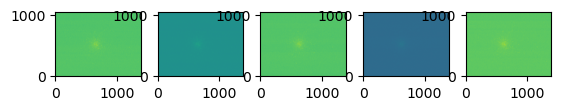

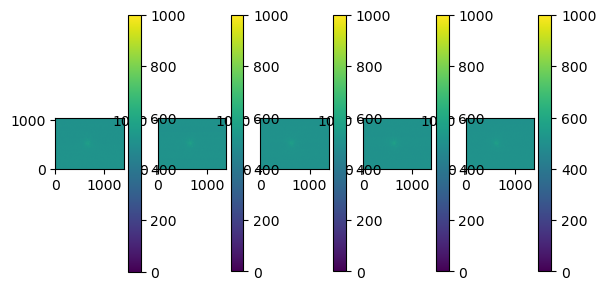

In [4]:
fig, axs = plt.subplots(1,5)

for x in range(1,6):
    with fits.open(f"../../course_assignments/homework10/M13_000{x}.fits") as hdul:
        header = hdul[0].header
        data = hdul[0].data
        axs[x-1].imshow(data, cmap = "viridis", origin = "lower")




fig2, axs = plt.subplots(1,5)

for x in range(1,6):
    with fits.open(f"../../course_assignments/homework10/M13_000{x}.fits") as hdul:
        header = hdul[0].header
        data = hdul[0].data
        im = axs[x-1].imshow(data, cmap = "viridis", origin = "lower", vmin = 0, vmax = 1000)
        plt.colorbar(im)
#I notice all the colors are very similar, which makes sense based on the individual color maps
#that I double checked with earlier.

510.4706668600796
512.0
509.7460150033157
511.0
508.0498729000884
510.0
507.90583554376656
509.0
508.7919920148099
510.0
509.0


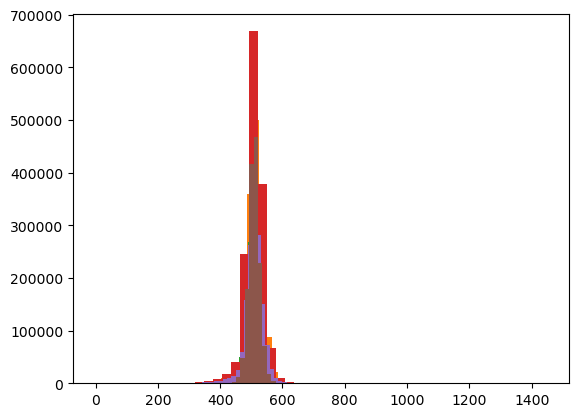

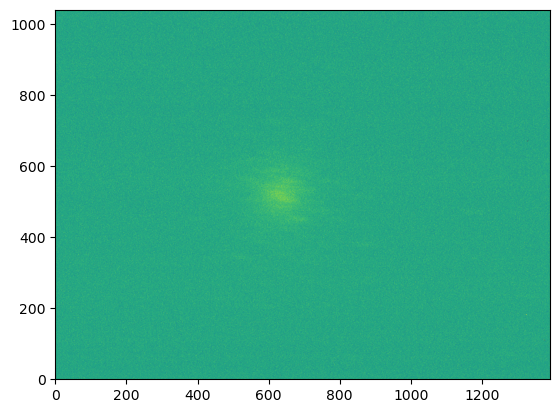

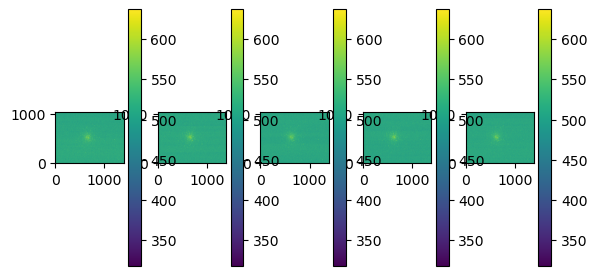

In [12]:
fulldata = None
with fits.open("../../course_assignments/homework10/M13_0001.fits") as hdul:
    fulldata = hdul[0].data
    
for x in range(1,6):
    with fits.open(f"../../course_assignments/homework10/M13_000{x}.fits") as hdul:
        header = hdul[0].header
        data = hdul[0].data
        plt.hist(data.ravel(), bins = 50)
        print(np.mean(data))
        print(np.median(data))
        #print(data)
        if x > 1:
            fulldata = fulldata + data
fulldata = fulldata / 5
print(np.median(fulldata))

plt.hist(fulldata.ravel(), bins = 50)
#x axis - brightness, y axis - number of times measured
#50 bins means there are 50 possible categories for values to fit in
#Most of the data is centered at 500.
#There is very little, looks like a Gaussian with a st. dev of ~50
#New median - 511
#318 to 637
plt.show()
plt.imshow(fulldata, cmap = "viridis", origin = "lower", vmin = 318, vmax = 637)
#Much more detailed image is visible now.
plt.show()
fig2, axs = plt.subplots(1,5)

fits.writeto("combined.fits", fulldata, overwrite=True)

for x in range(1,6):
    with fits.open(f"../../course_assignments/homework10/M13_000{x}.fits") as hdul:
        header = hdul[0].header
        data = hdul[0].data
        im = axs[x-1].imshow(data, cmap = "viridis", origin = "lower", vmin = 318, vmax = 637)
        plt.colorbar(im)
